In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import dataAgglomeration as da
import numpy as np
from numpy import linalg
import math

In [3]:
pa = pd.read_csv('bubblepproc.dat', sep="\t", header=0)

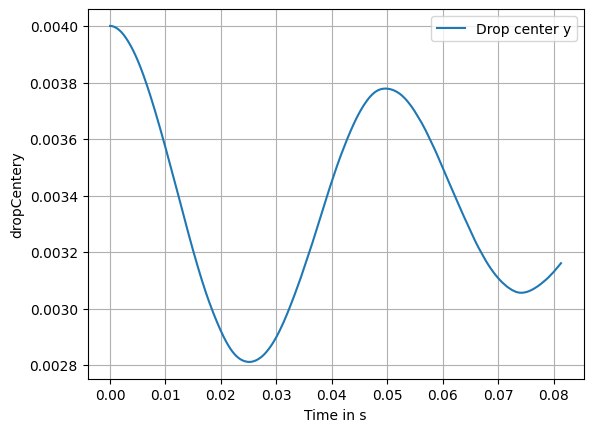

In [5]:
plt.plot(pa["time"].iloc[1:], pa["bubbleCentery"].iloc[1:], label="Drop center y")

plt.xlabel("Time in s")
plt.ylabel("dropCentery")
plt.grid()
plt.legend()
plt.savefig('DropCentery.png', facecolor='w',dpi=400)
plt.show()

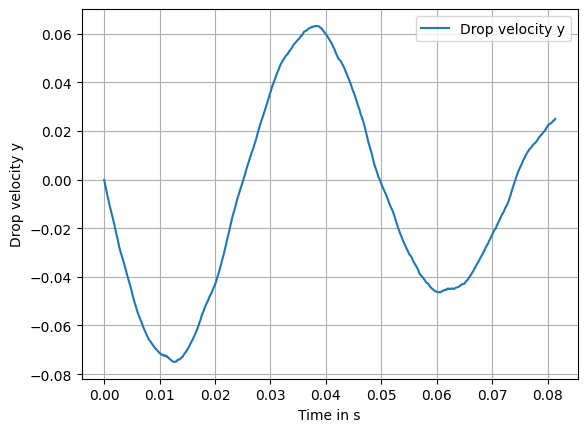

In [6]:
plt.plot(pa["time"].iloc[1:], pa["y-Velocity"].iloc[1:], label="Drop velocity y")

plt.xlabel("Time in s")
plt.ylabel("Drop velocity y")
plt.grid()
plt.legend()
plt.savefig('DropVely.png', facecolor='w',dpi=400)
plt.show()

In [4]:
### Results from interFlow
agglomerator = da.data_agglomerator("risingBubbleAcc3D.parameter","bubblepproc.dat", 
                                     "./isoAdv-risingBubbleAcc3D_00000_templateCase")
agglomerator.show_failed_variations()
agglomerator.write_agglomerated_study_data("isoAdv-risingBubbleAcc3D.csv")
dframe_isoAdv_risingU = agglomerator.study_dataframe()
dframe_isoAdv_risingU = dframe_isoAdv_risingU.sort_index()


Variants without valid data:
----------------------------
#Variation | Reason
----------------------------
[[0.00486], [0], [0], [0], [1e-07], [0.0001], [0], [4], [15], [1e-07], [1e-09], ['triangleInCell'], ['compactDivGrad'], ['cellPoint'], ['Euler'], [10], [0], [0.001], [0.5], [0.02], [1], [3], [120], [240, 480], [-9.80665], [0.0728], [3.009e-05], [998.21], [1.5111e-05], [1.2047], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]]
['radius', 'z_centre', 'y_centre', 'x_centre', 'abs_phi_change_tolerance', 'phi_change_tolerance', 'n_non_orth_correctors', 'n_correctors', 'n_outer_correctors', 'u_tol', 'p_tol', 'front_to_mesh_transfer', 'curvature_

In [6]:
df20 = dframe_isoAdv_risingU.loc[dframe_isoAdv_risingU.index.get_level_values('resolution') == 240]
df40 = dframe_isoAdv_risingU.loc[dframe_isoAdv_risingU.index.get_level_values('resolution') == 480]

In [15]:
#df20[["x-Velocity","y-Velocity","z-Velocity"]]
accN20 = linalg.norm(df20[["x-Velocity","y-Velocity","z-Velocity"]].diff(), axis=1)/df20["time"].diff()
accN40 = linalg.norm(df40[["x-Velocity","y-Velocity","z-Velocity"]].diff(), axis=1)/df40["time"].diff()

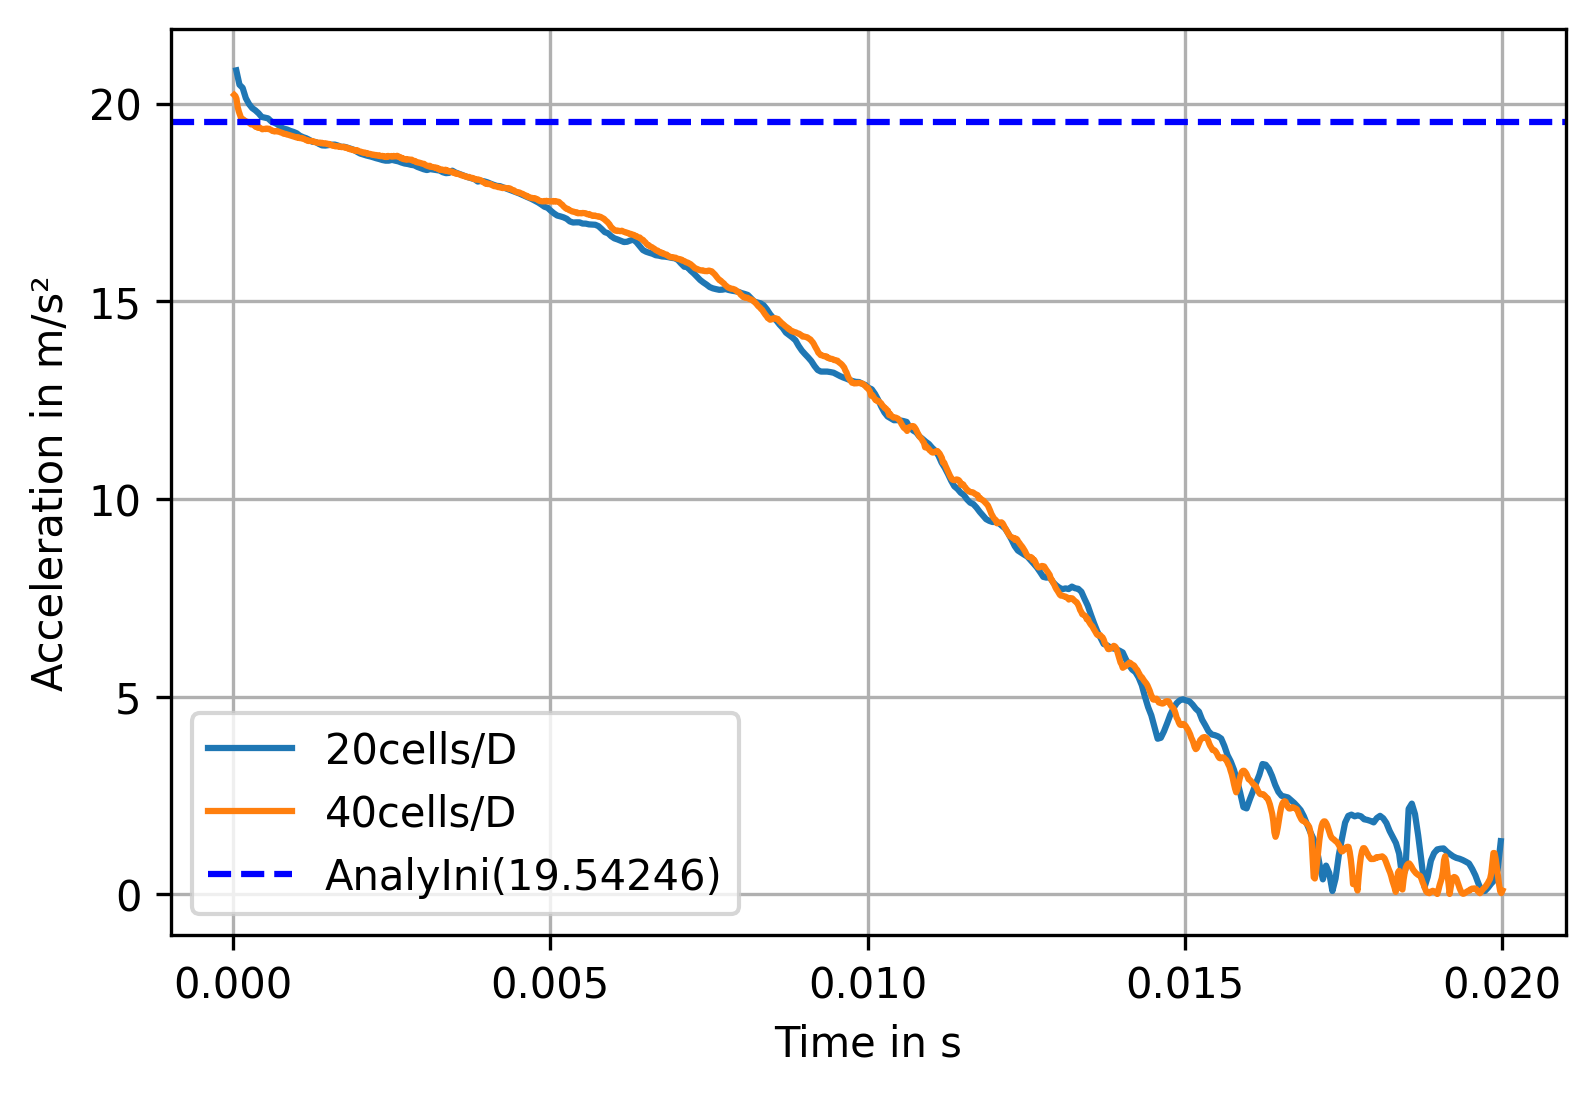

In [35]:
rcParams["figure.dpi"] = 300
g = 9.80665
rhol= 998.21
rhog = 1.2047

acc = 2*g*(rhol - rhog)/(rhol+2*rhog)
t=np.linspace(0,0.02)
vel=acc*t


plt.plot(df20["time"], accN20, label="20cells/D")
plt.plot(df40["time"], accN40, label="40cells/D")
plt.axhline(y=acc, linestyle='--', color='blue', label="AnalyIni(19.54246)")
#plt.xlim(0,0.001)
#plt.ylim(18)
plt.xticks([0,0.005,0.01,0.015,0.02])
#plt.plot(t, vel, label="Analytical")
plt.xlabel("Time in s")
plt.ylabel("Acceleration in m/s²")
plt.grid()
plt.legend()
plt.savefig('accPlot_zoomedIn.png', facecolor='w')
plt.show()


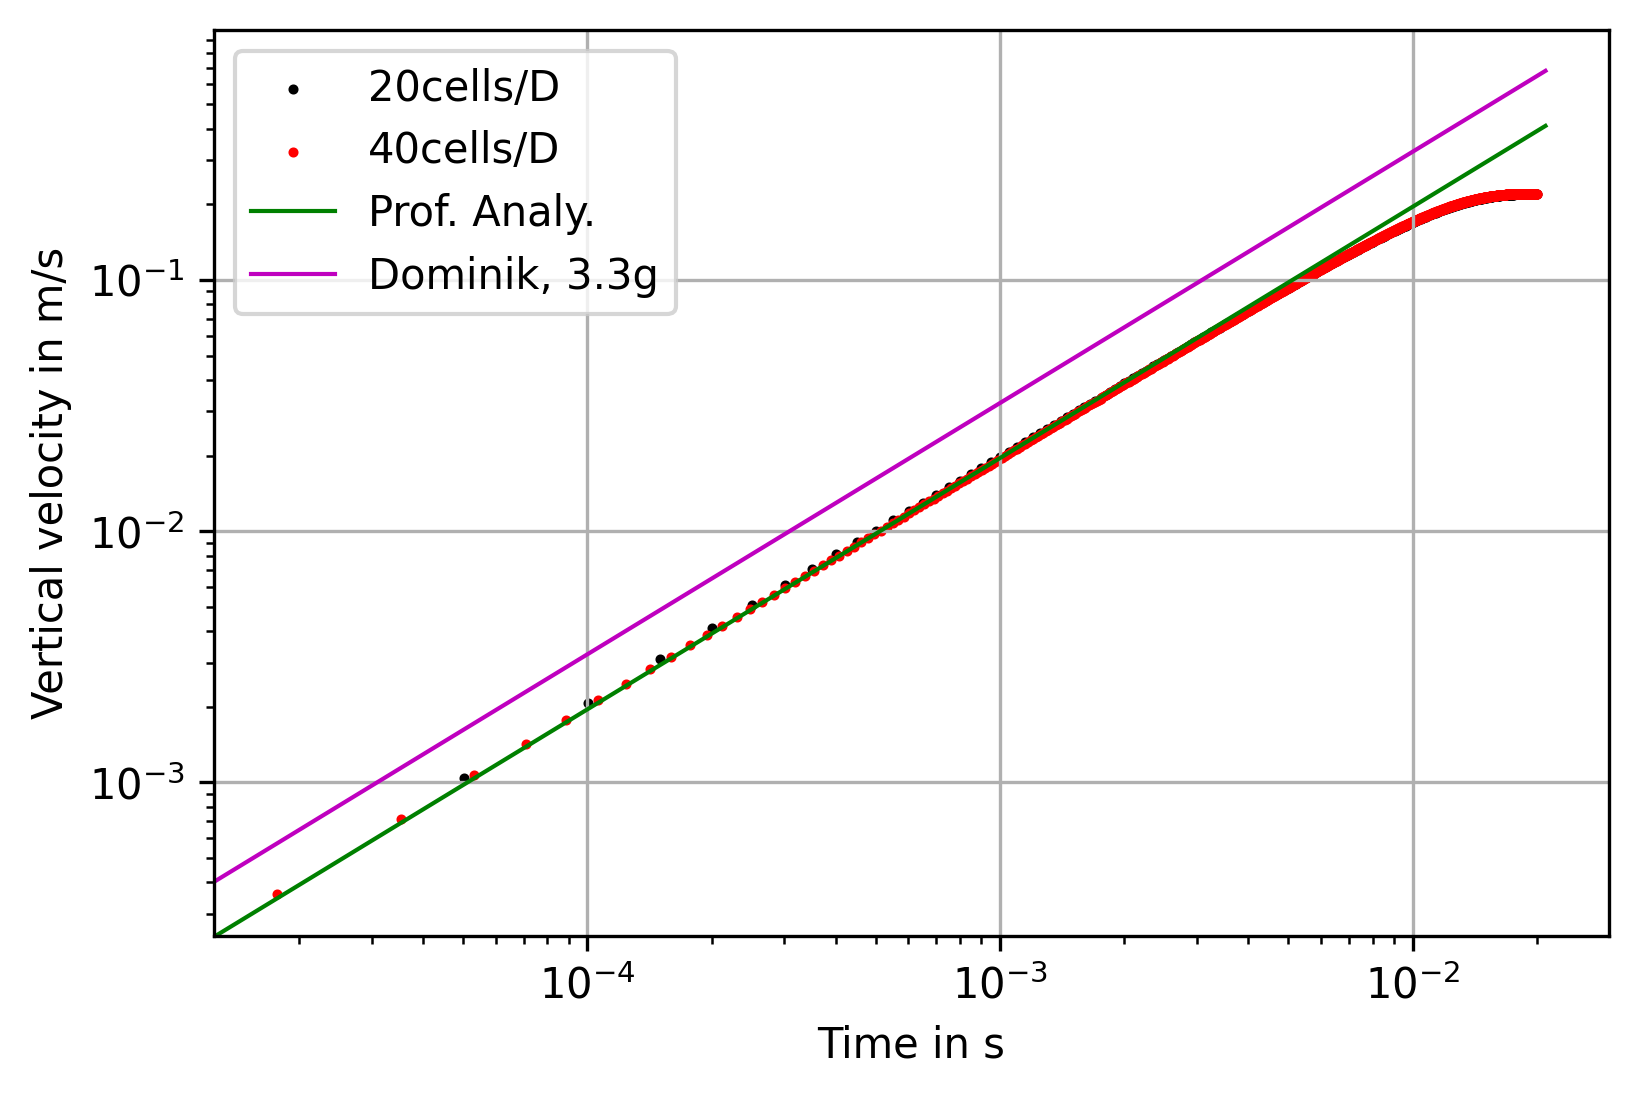

In [72]:
#plt.plot(df20["time"], df20["z-Velocity"], label="20cells/D", marker="o", markevery=10)
plt.scatter(df20["time"], df20["z-Velocity"],s=2, label="20cells/D", color='black')
#plt.plot(df40["time"], df40["z-Velocity"], label="40cells/D", marker="o", markevery=20)
plt.scatter(df40["time"], df40["z-Velocity"], s=2,label="40cells/D", color='red')
#plt.axhline(y=math.log(acc), linestyle='--', color='blue', label="AnalyIni(19.54246)")
#plt.xlim(0,0.001)
#plt.ylim(18)
axes = plt.gca()
xVal= np.linspace(0, 0.021, num=1000)#df40["time"] #np.array(axes.get_xlim())
yVal1= acc*xVal
yVal2= 3.3*g*xVal

plt.plot(xVal, yVal1,color='g', label="Prof. Analy.", linewidth=1)
plt.plot(xVal, yVal2, color='m', label="Dominik, 3.3g", linewidth=1)
plt.xlabel("Time in s")
plt.ylabel("Vertical velocity in m/s")
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.legend()
plt.savefig('VelTimeLogScale.png', facecolor='w', dpi=300)
plt.show()

In [59]:
xVal

array([-0.00100041,  0.02100851])

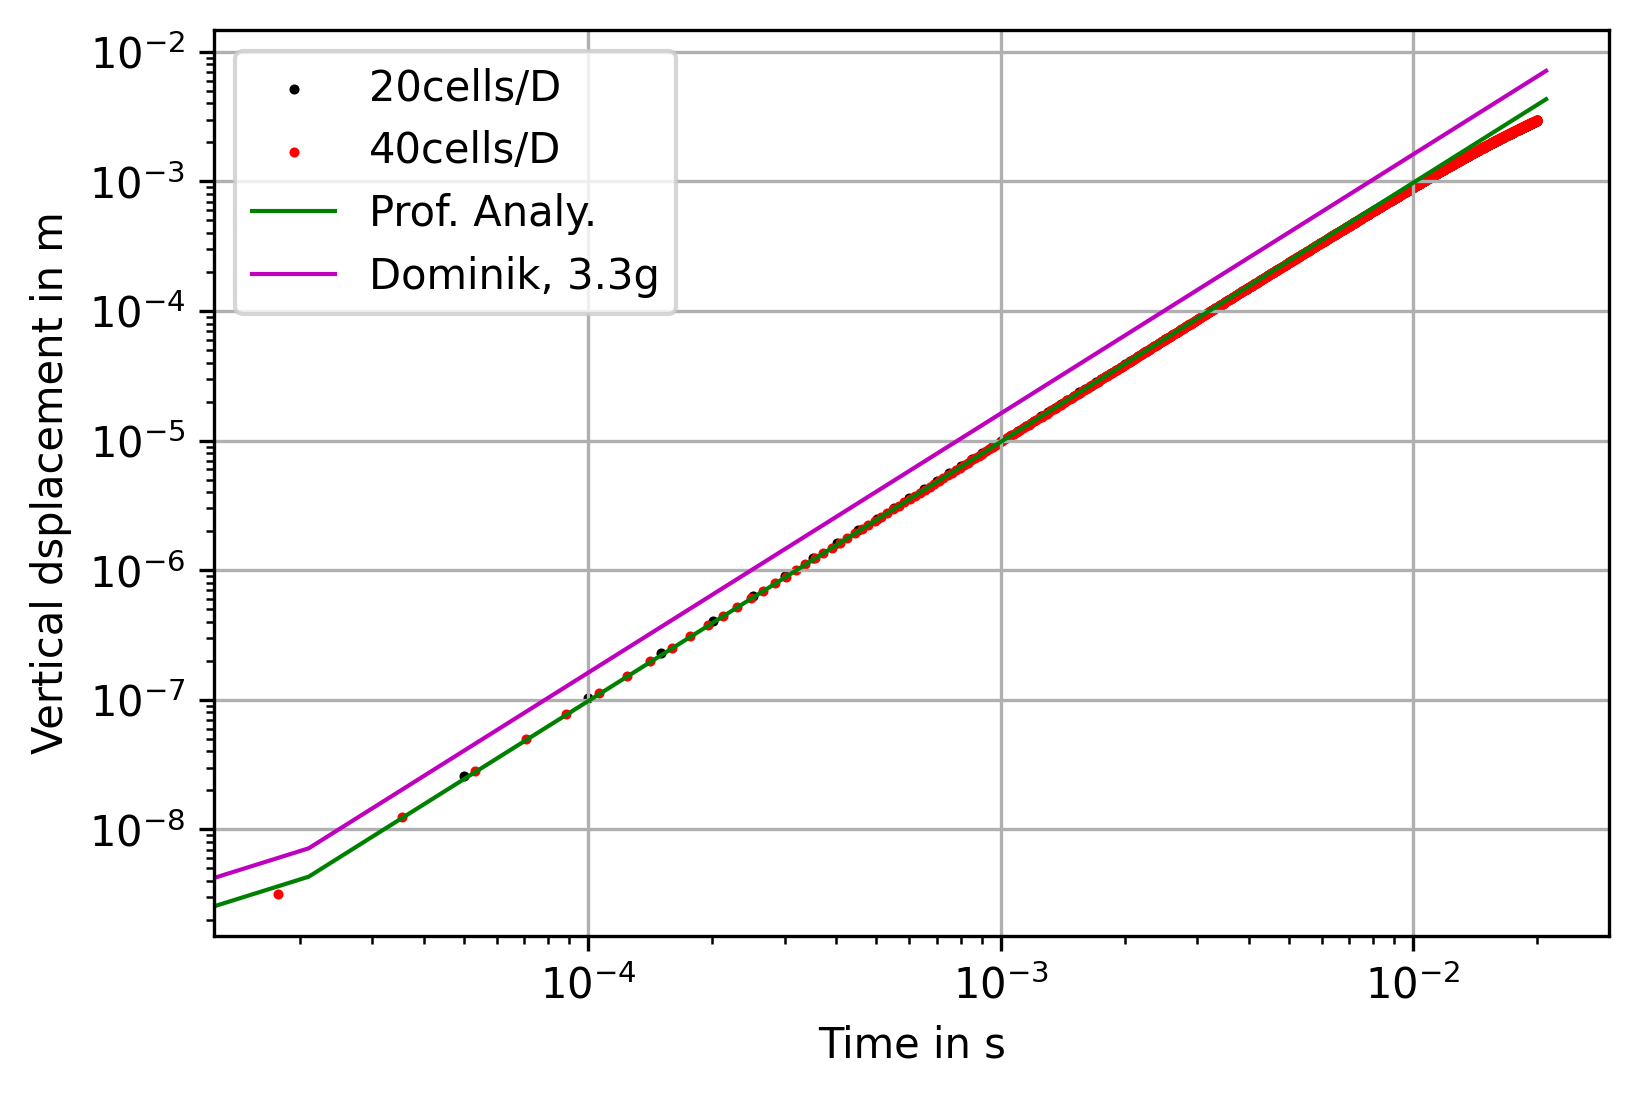

In [73]:
#plt.plot(df20["time"], df20["z-Velocity"], label="20cells/D", marker="o", markevery=10)
plt.scatter(df20["time"], df20["bubbleCenterz"],s=2, label="20cells/D", color='black')
#plt.plot(df40["time"], df40["z-Velocity"], label="40cells/D", marker="o", markevery=20)
plt.scatter(df40["time"], df40["bubbleCenterz"], s=2,label="40cells/D", color='red')
#plt.axhline(y=math.log(acc), linestyle='--', color='blue', label="AnalyIni(19.54246)")
#plt.xlim(0,0.001)
#plt.ylim(18)
#axes = plt.gca()
xVal = np.linspace(0, 0.021, num=1000) #np.random.uniform(low=0.0, high=0.021, size=(50,)) #np.array(axes.get_xlim())
yVal1= 0.5*acc*xVal*xVal
yVal2= 0.5*3.3*g*xVal*xVal

plt.plot(xVal, yVal1, color='green', label="Prof. Analy.", linewidth=1)
plt.plot(xVal, yVal2, color='m', label="Dominik, 3.3g", linewidth=1)
plt.xlabel("Time in s")
plt.ylabel("Vertical dsplacement in m")
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.legend()
plt.savefig('DispTimeLogScale.png', facecolor='w',dpi=300)
plt.show()

In [55]:
xVal**2

array([1.00081016e-06, 4.41357282e-04])

In [56]:
xVal

array([-0.00100041,  0.02100851])

In [60]:
xVal = np.random.uniform(low=0.0, high=0.021, size=50)

In [61]:
xVal

array([0.00623508, 0.00709649, 0.00086591, 0.01247745, 0.01578865,
       0.01852986, 0.00551276, 0.00858739, 0.00719606, 0.01857203,
       0.02088652, 0.00152737, 0.01325764, 0.02035066, 0.01311833,
       0.00965863, 0.02024088, 0.00502182, 0.01584723, 0.00896678,
       0.01733302, 0.01736371, 0.01634209, 0.00436992, 0.01369149,
       0.01567962, 0.00247744, 0.01146631, 0.01193597, 0.00237793,
       0.00013707, 0.01858927, 0.00931514, 0.01465121, 0.013464  ,
       0.02092311, 0.00503126, 0.01244191, 0.01647002, 0.00729031,
       0.00873954, 0.01753792, 0.01623358, 0.01793259, 0.01821547,
       0.01553681, 0.01157849, 0.00748065, 0.0022044 , 0.01701364])

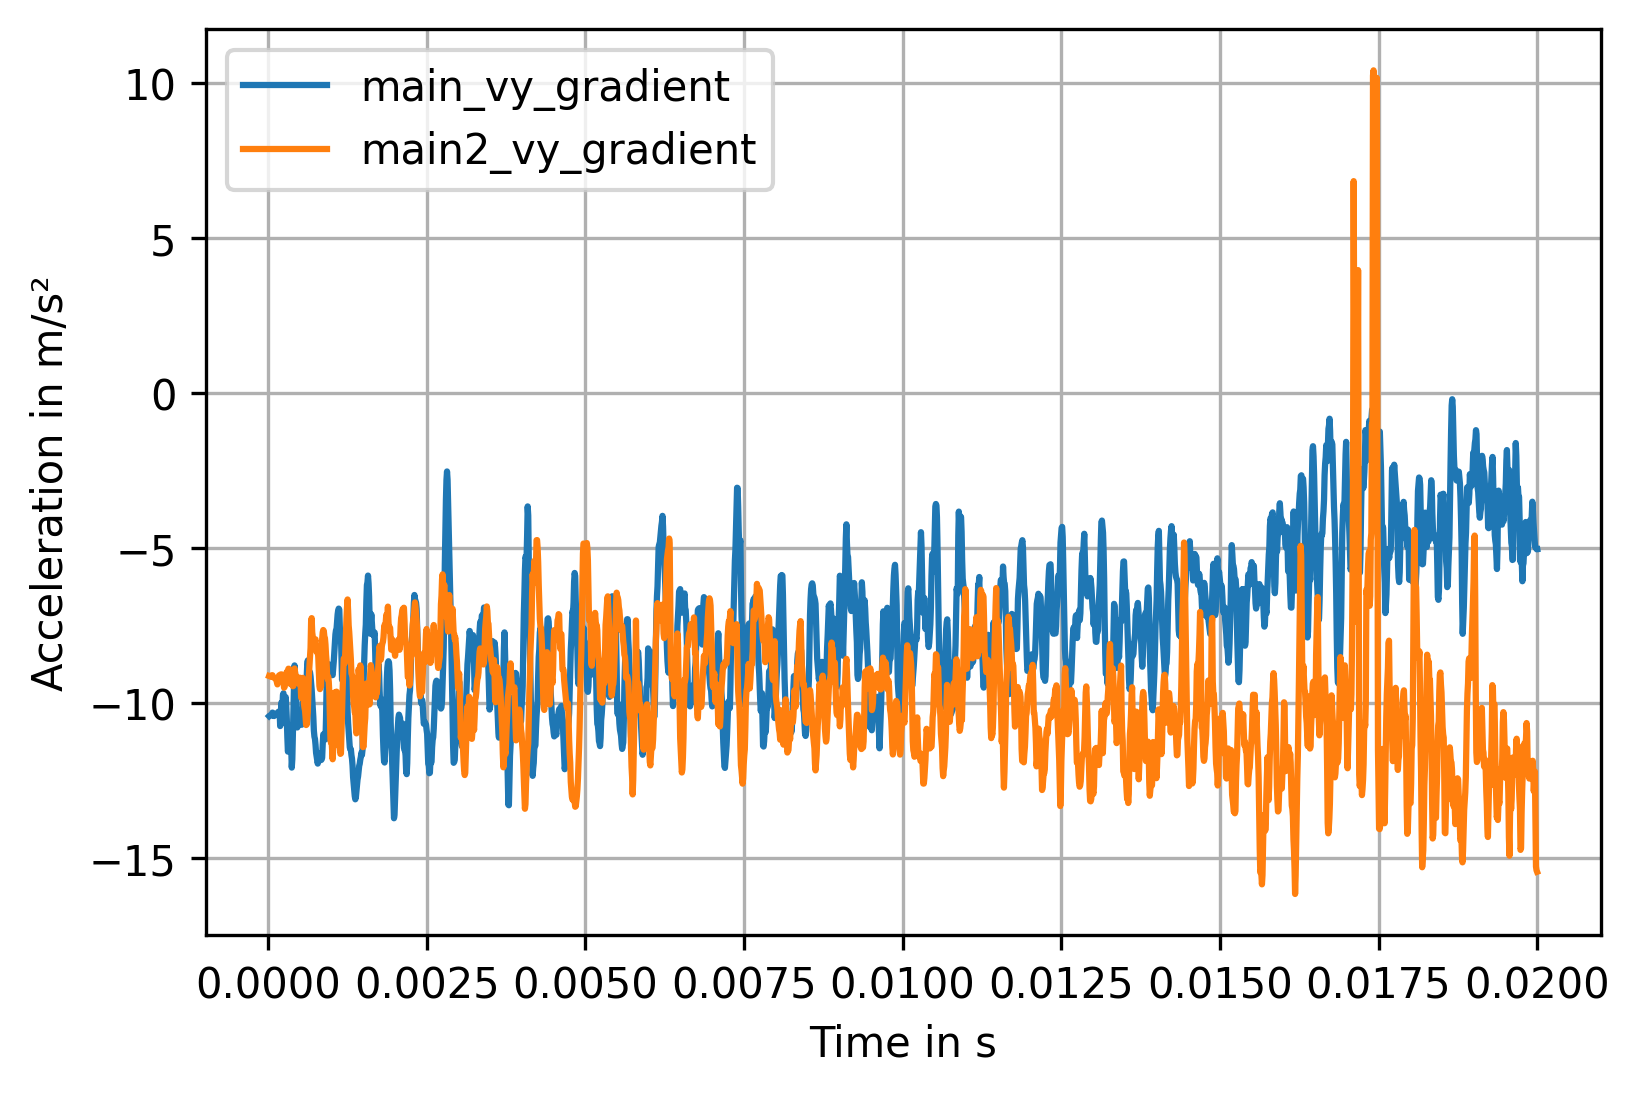

In [34]:
main = pd.read_csv('bubblepproc.dat', sep="\t", header=0)

accmain = linalg.norm(main[["x-Velocity","y-Velocity","z-Velocity"]].diff(), axis=1)/main["time"].diff()

rcParams["figure.dpi"] = 300
g = 9.80665
rhol= 997
rhog = 1.225

acc = 2*g*(rhol - rhog)/(rhol+2*rhog)

#plt.plot(timeStepMinus9["time"].iloc[2:], np.diff(timeStepMinus9["bubbleCenterz"], n=2)/1e-9**2,label="test")

main2 = pd.read_csv('../main2/bubblepproc.dat', sep="\t", header=0)

accmain2 = linalg.norm(main2[["x-Velocity","y-Velocity","z-Velocity"]].diff(), axis=1)/main2["time"].diff()

#plt.plot(main["time"].iloc[2:], accmain.iloc[2:], label="main")
#plt.plot(main2["time"].iloc[2:], accmain2.iloc[2:], label="main2")

plt.plot(main["time"].iloc[2:], np.gradient(main['y-Velocity'], main['time'])[2:],label="main_vy_gradient")
plt.plot(main2["time"].iloc[2:], np.gradient(main2['y-Velocity'], main2['time'])[2:],label="main2_vy_gradient")

#plt.plot(timeStepMinus9["time"], accMinus9, label="Acc")

#plt.plot(timeStepMinus8["time"].iloc[::10], accMinus8.iloc[::10], label="timeStepMinus8")

#plt.plot(timeStepMinus8["time"], accMinus8, label="timeStepMinus8_default")
#plt.plot(timeStepMinus8["time"].iloc[1:], timeStepMinus8["z-Velocity"].iloc[1:]/timeStepMinus8["time"].iloc[1:]  , label="timeStepMinus8_newEva")
#plt.plot(timeStepMinus81["time"], accMinus81, label="timeStepMinus81", alpha=0.6)
#plt.plot(timeStepMinus82["time"], accMinus82, label="timeStepMinus8_smallIniDt", alpha=0.8)

#plt.plot(timeStepMinus810["time"], accMinus810, label=r"$\Delta t = 10^{-8}s$, noST", alpha=0.8)
#plt.plot(timeStepMinus831["time"], accMinus831, label="timeStepMinus8_noSurfaceTension", alpha=0.8)

#plt.plot(timeStepMinus84["time"], accMinus84, label="timeStepMinus8_gravityRecon", alpha=0.8)
#plt.plot(timeStepMinus85["time"], accMinus85, label="timeStepMinus8_gravityRecon2", alpha=0.6)
#plt.plot(timeStepMinus86["time"], accMinus86, label="timeStepMinus8_noST_smallIni", alpha=0.6)
#plt.plot(timeStepMinus7["time"], accMinus7, label="timeStepMinus7")

#plt.plot(timeStepMinus87["time"], accMinus87, label="timeStepMinus8_interFlow")
#plt.plot(timeStepMinus88["time"], accMinus88, label="timeStepMinus8_interGravFlow", alpha=0.6)
#plt.plot(timeStepMinus89["time"], accMinus89, label="timeStepMinus8_vofIni", alpha=0.6)

#plt.plot(timeStepMinus6["time"], accMinus6, label="timeStepMinus6")
#plt.plot(timeStepMinus61["time"], accMinus61, label="timeStepMinus6_smallIniDt", alpha=0.8)

#plt.plot(timeStepMinus5["time"], accMinus5, label="timeStepMinus5")
#plt.axhline(y=acc, linestyle='--', color='blue', label=r"$2$g$\frac{\rho_l-\rho_g}{\rho_l+2\rho_g}$")
#plt.xlim(0,1e-5) #7.1e-5)
#plt.ylim(18)
#plt.xticks([0,0.005,0.01,0.015,0.02])
#plt.plot(t, vel, label="Analytical")
plt.xlabel("Time in s")
plt.ylabel("Acceleration in m/s²")
plt.grid()
plt.legend()
#plt.savefig('accPlot_timeStepMinus8_noST.png', facecolor='w',dpi=300)
plt.show()

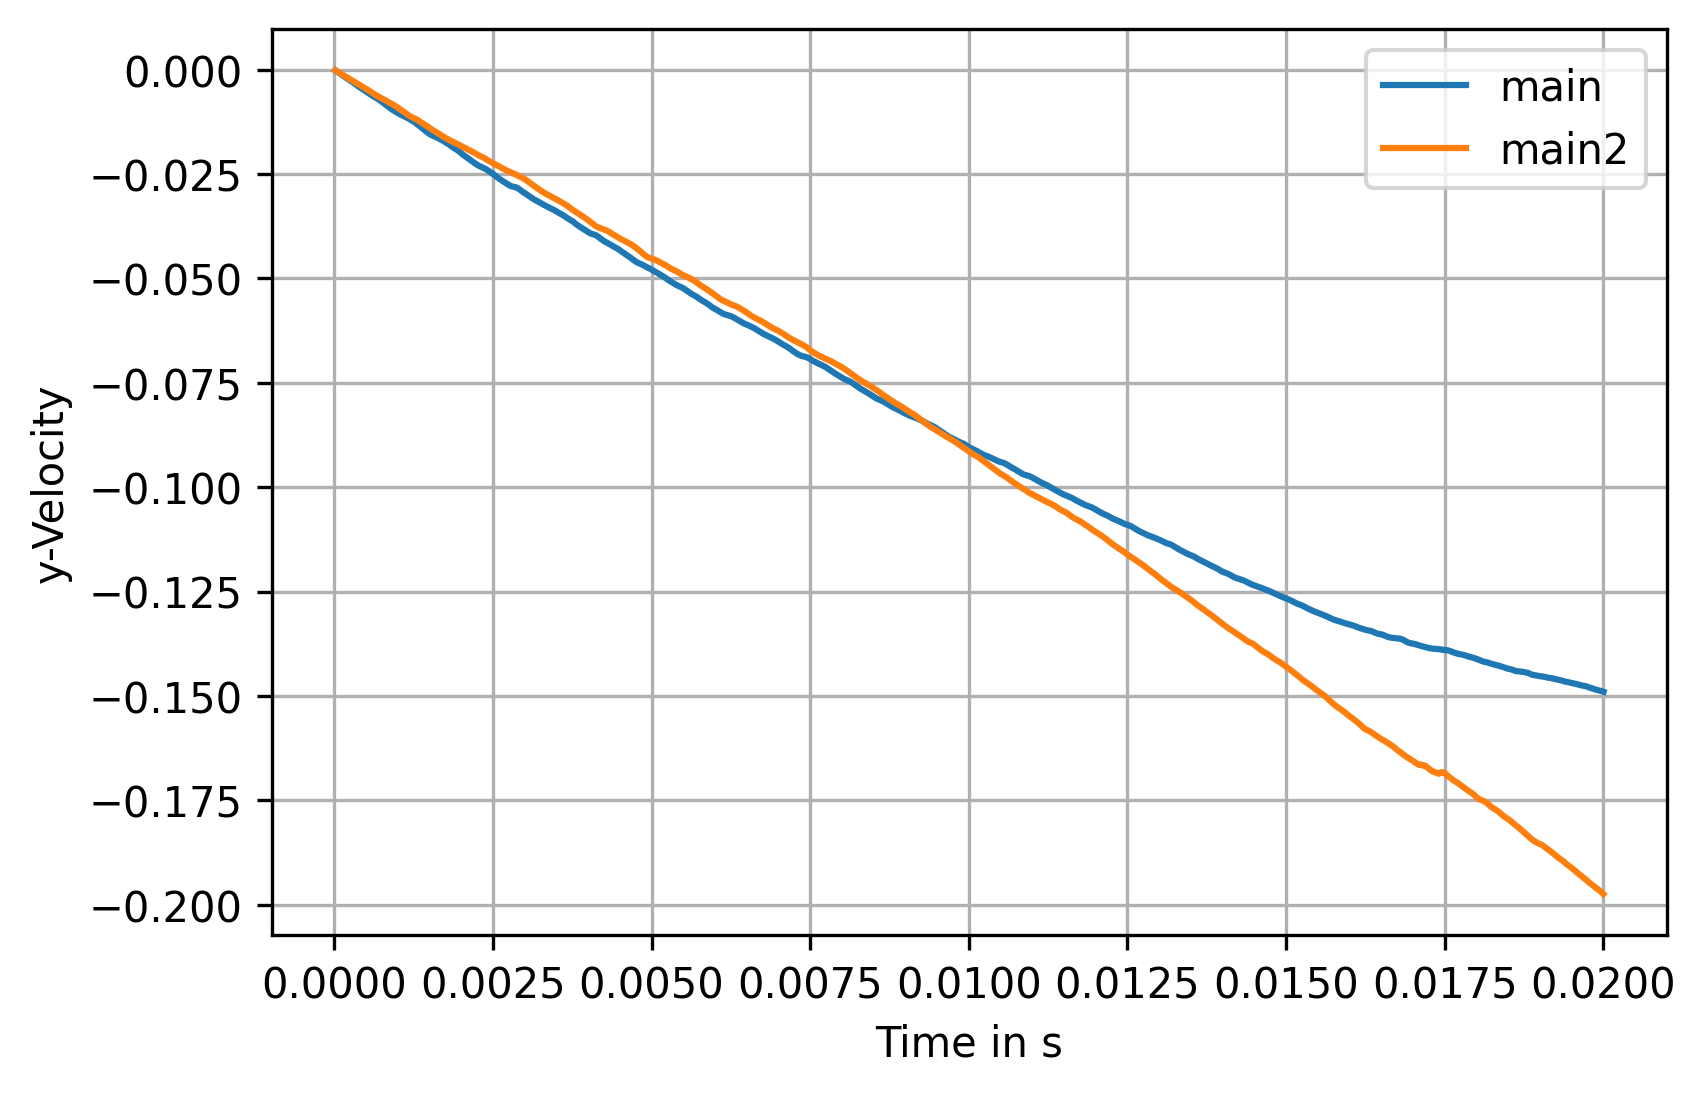

In [35]:
plt.plot(main["time"].iloc[2:], main["y-Velocity"].iloc[2:], label="main")
plt.plot(main2["time"].iloc[2:], main2["y-Velocity"].iloc[2:], label="main2")

plt.xlabel("Time in s")
plt.ylabel("y-Velocity")
plt.grid()
plt.legend()
#plt.savefig('accPlot_timeStepMinus8_noST.png', facecolor='w',dpi=300)
plt.show()

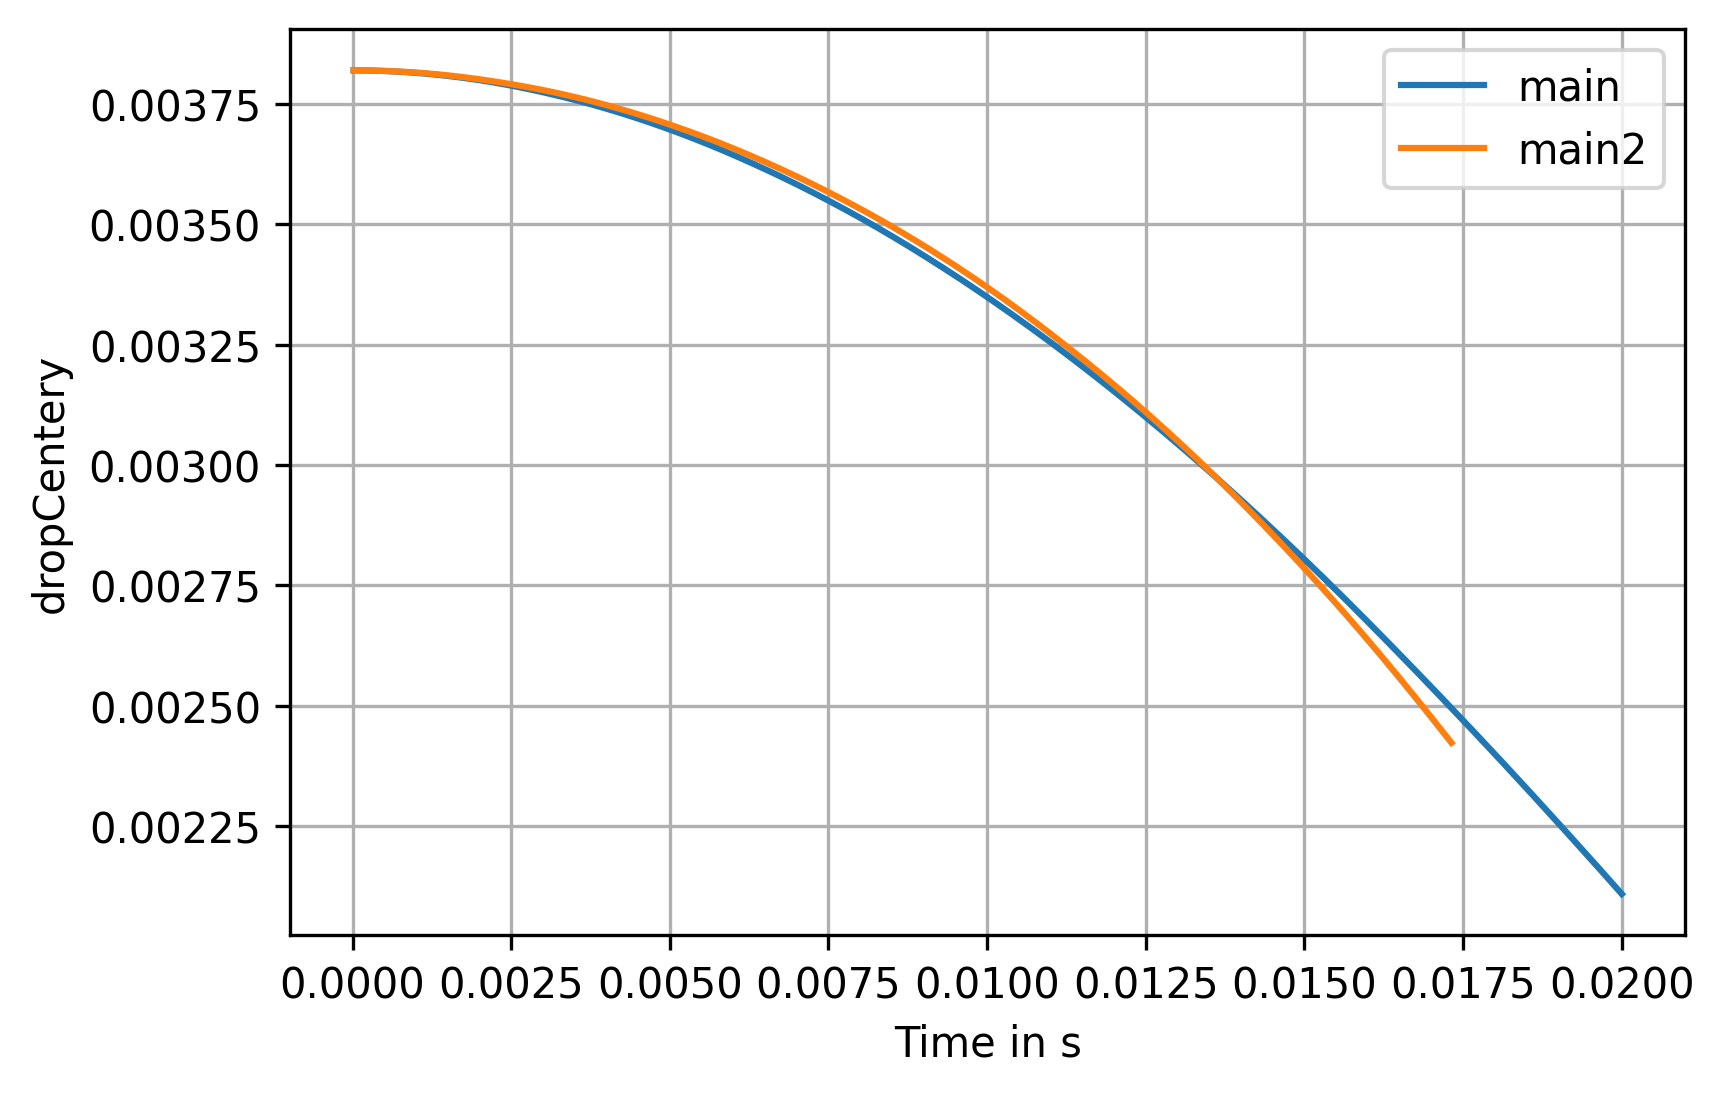

In [29]:
plt.plot(main["time"].iloc[2:], main["bubbleCentery"].iloc[2:], label="main")
plt.plot(main2["time"].iloc[2:], main2["bubbleCentery"].iloc[2:], label="main2")

plt.xlabel("Time in s")
plt.ylabel("dropCentery")
plt.grid()
plt.legend()
#plt.savefig('accPlot_timeStepMinus8_noST.png', facecolor='w',dpi=300)
plt.show()

In [18]:
main2

,time,magVelocity,x-Velocity,y-Velocity,z-Velocity,bubbleVolume,bubbleArea,bubbleAreaPLIC,bubbleCenterx,bubbleCentery,bubbleCenterz,radiusA,radiusB,sphericity,sphericityPLIC
0,0.000000,0.000079,-6.937471e-08,-0.000079,-1.416159e-29,6.276664e-10,0.000001,0.000001,0.029000,0.003820,-1.148455e-21,0.000531,0.000316,2.824556,2.817356
1,0.000009,0.000079,-6.937471e-08,-0.000079,-1.416159e-29,6.276664e-10,0.000001,0.000001,0.029000,0.003820,-1.148455e-21,0.000531,0.000316,2.824556,2.817356
2,0.000017,0.000159,-1.419790e-07,-0.000159,-1.042870e-29,6.276664e-10,0.000001,0.000001,0.029000,0.003820,-1.149195e-21,0.000531,0.000316,2.824561,2.816844
3,0.000026,0.000238,-2.117953e-07,-0.000238,-5.420027e-30,6.276664e-10,0.000001,0.000001,0.029000,0.003820,-1.150251e-21,0.000531,0.000316,2.824682,2.816078
4,0.000035,0.000318,-2.826210e-07,-0.000318,7.026711e-31,6.276664e-10,0.000001,0.000001,0.029000,0.003820,-1.151518e-21,0.000531,0.000316,2.824684,2.815118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1206,0.010500,0.096782,-6.177296e-04,-0.096780,1.566819e-27,6.276664e-10,0.000001,0.000001,0.028999,0.003322,1.367202e-21,0.000531,0.000316,2.823431,2.711968
1207,0.010509,0.096860,-6.056282e-04,-0.096858,1.309067e-27,6.276664e-10,0.000001,0.000001,0.028999,0.003322,1.394872e-21,0.000531,0.000316,2.823496,2.715725
1208,0.010517,0.096941,-5.941702e-04,-0.096939,8.144923e-28,6.276664e-10,0.000001,0.000001,0.028999,0.003321,1.417714e-21,0.000531,0.000316,2.823466,2.724354
1209,0.010526,0.097017,-5.808497e-04,-0.097015,5.058725e-28,6.276664e-10,0.000001,0.000001,0.028999,0.003320,1.435707e-21,0.000531,0.000316,2.823523,2.726971


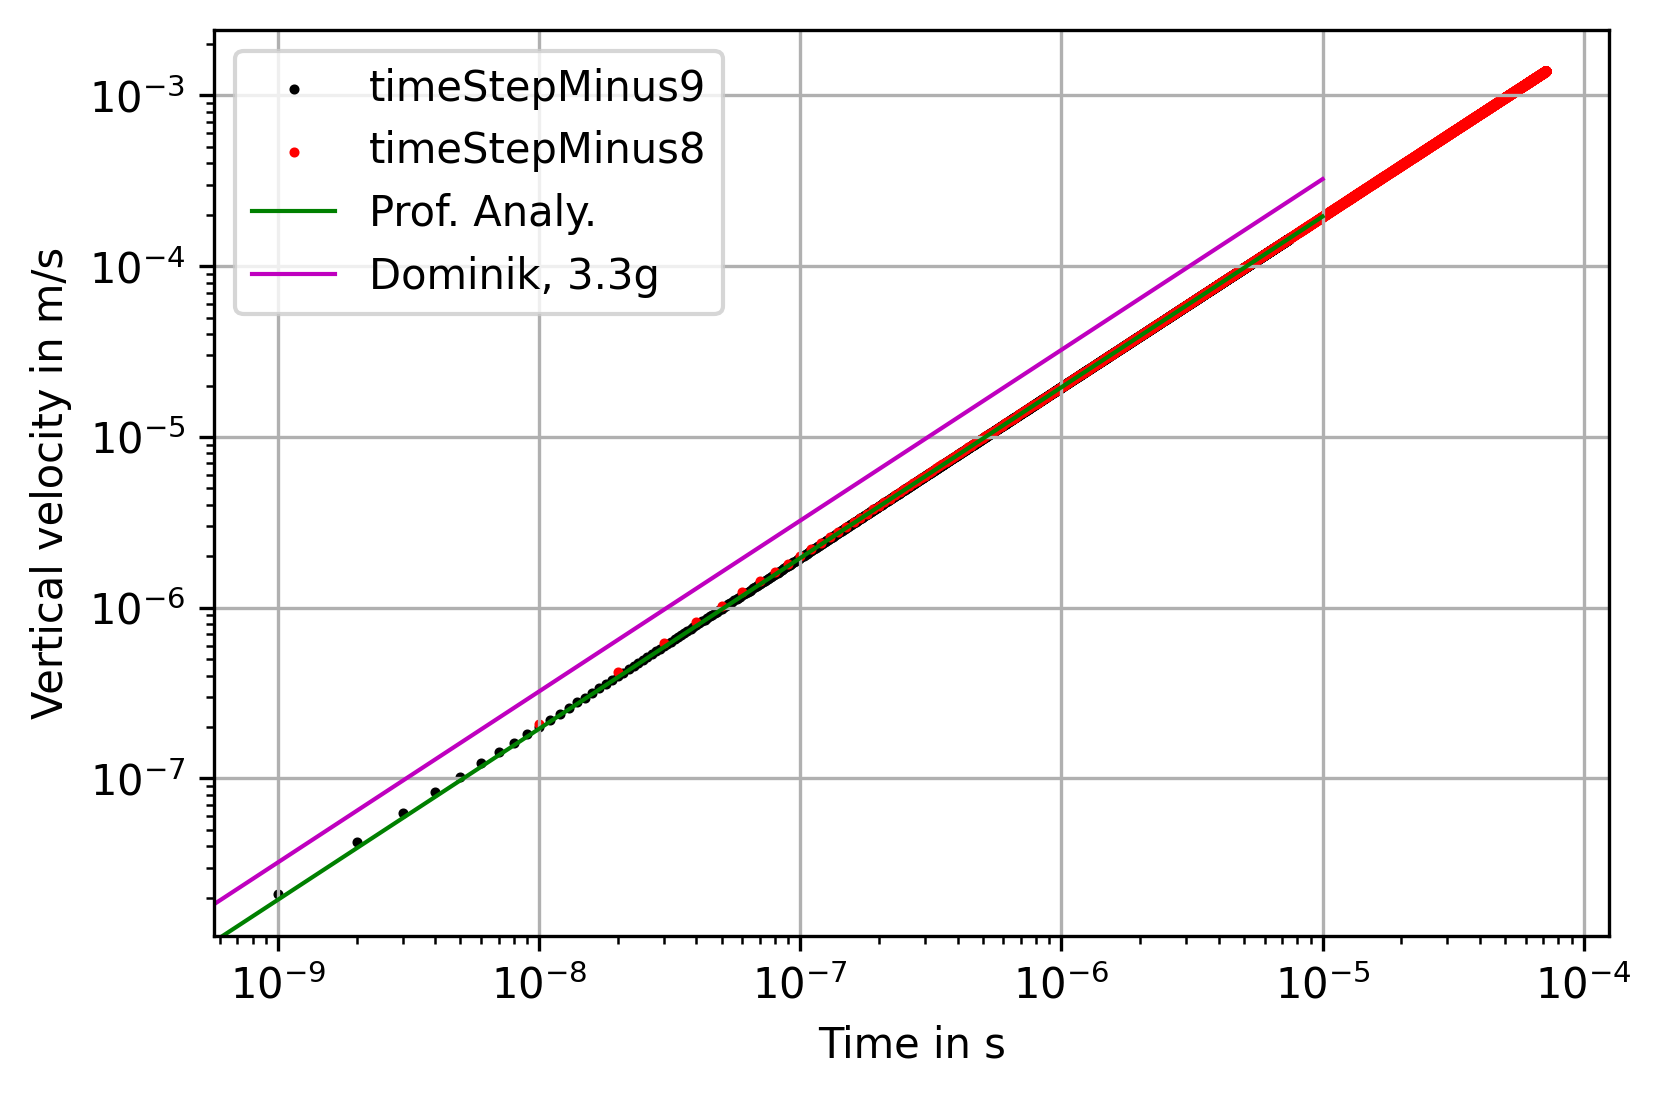

In [90]:
#plt.plot(df20["time"], df20["z-Velocity"], label="20cells/D", marker="o", markevery=10)
plt.scatter(timeStepMinus9["time"], timeStepMinus9["z-Velocity"],s=2, label="timeStepMinus9", color='black')
#plt.plot(df40["time"], df40["z-Velocity"], label="40cells/D", marker="o", markevery=20)
plt.scatter(timeStepMinus8["time"], timeStepMinus8["z-Velocity"], s=2,label="timeStepMinus8", color='red')
#plt.axhline(y=math.log(acc), linestyle='--', color='blue', label="AnalyIni(19.54246)")
#plt.xlim(0,0.001)
#plt.ylim(18)
axes = plt.gca()
xVal= np.linspace(0, 1e-5, num=1000)#df40["time"] #np.array(axes.get_xlim())
yVal1= acc*xVal
yVal2= 3.3*g*xVal

plt.plot(xVal, yVal1,color='g', label="Prof. Analy.", linewidth=1)
plt.plot(xVal, yVal2, color='m', label="Dominik, 3.3g", linewidth=1)
plt.xlabel("Time in s")
plt.ylabel("Vertical velocity in m/s")
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.legend()
plt.savefig('smallDelT_VtLogScale.png', facecolor='w', dpi=300)
plt.show()

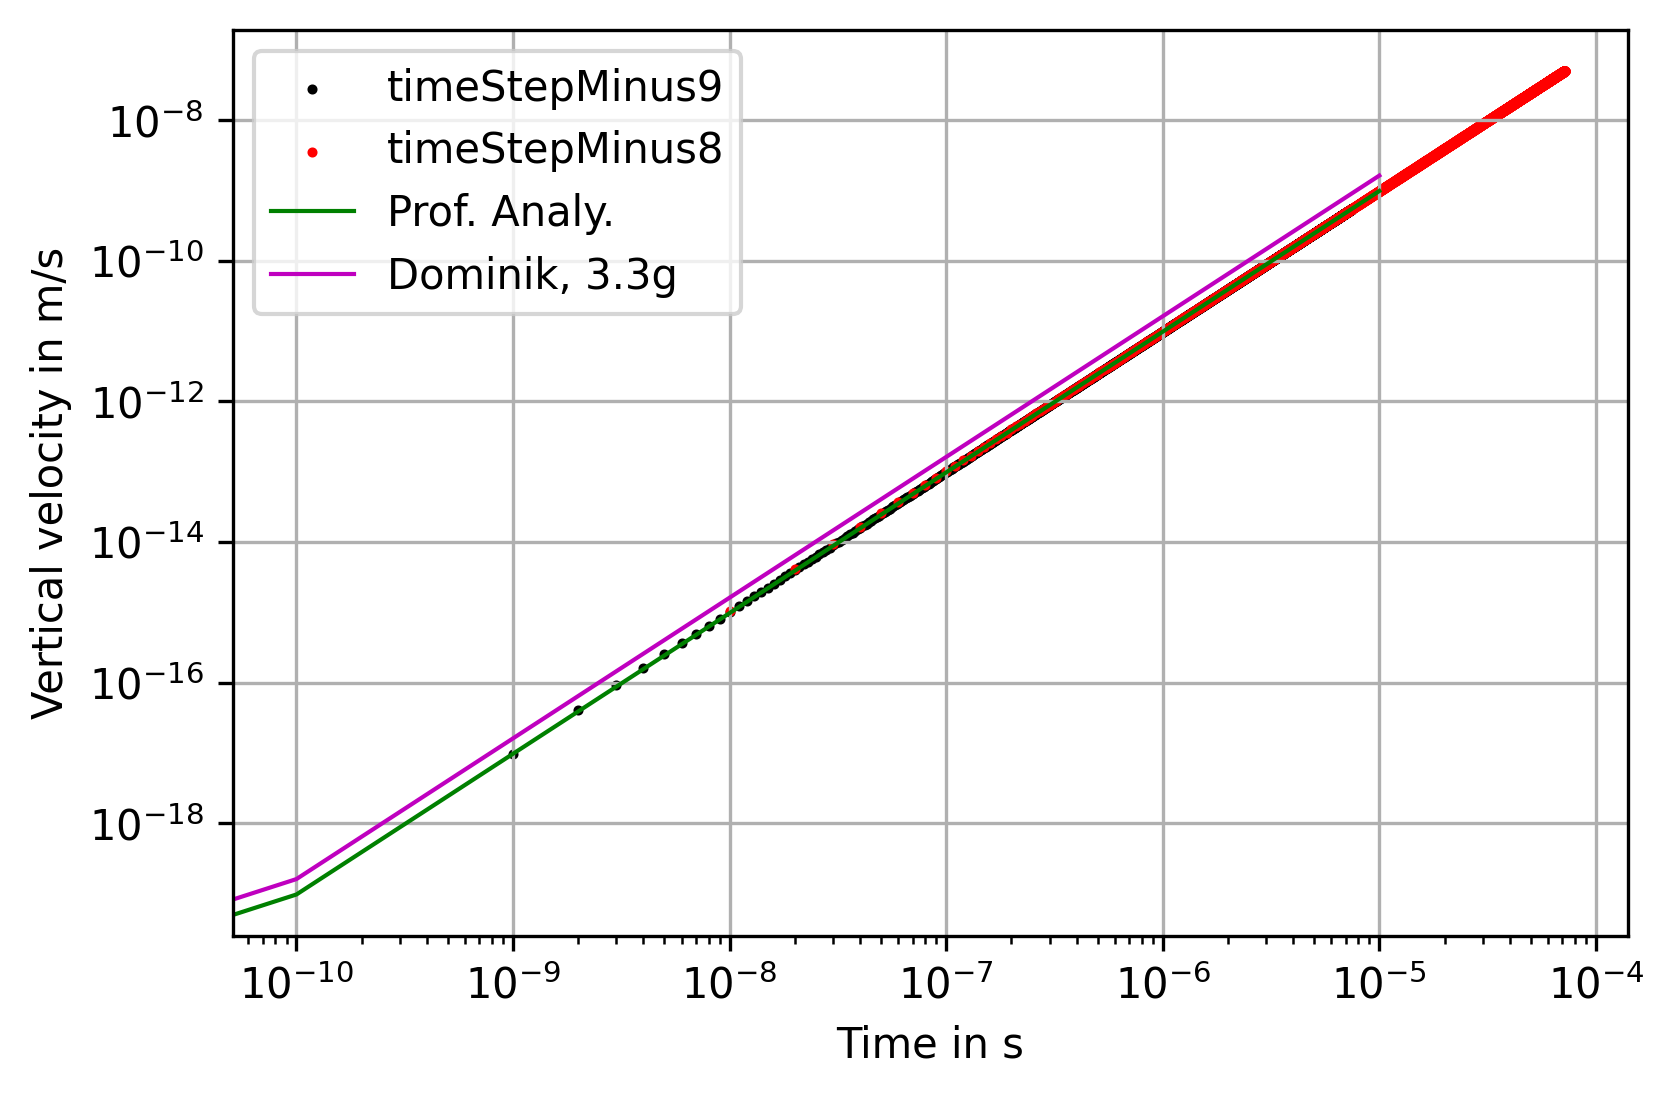

In [89]:
#plt.plot(df20["time"], df20["z-Velocity"], label="20cells/D", marker="o", markevery=10)
plt.scatter(timeStepMinus9["time"], timeStepMinus9["bubbleCenterz"],s=2, label="timeStepMinus9", color='black')
#plt.plot(df40["time"], df40["z-Velocity"], label="40cells/D", marker="o", markevery=20)
plt.scatter(timeStepMinus8["time"], timeStepMinus8["bubbleCenterz"], s=2,label="timeStepMinus8", color='red')
#plt.axhline(y=math.log(acc), linestyle='--', color='blue', label="AnalyIni(19.54246)")
#plt.xlim(0,0.001)
#plt.ylim(18)
axes = plt.gca()
xVal= np.linspace(0, 1e-5, num=100000)#df40["time"] #np.array(axes.get_xlim())
yVal1= 0.5*acc*xVal*xVal
yVal2= 0.5*3.3*g*xVal*xVal

plt.plot(xVal, yVal1,color='g', label="Prof. Analy.", linewidth=1)
plt.plot(xVal, yVal2, color='m', label="Dominik, 3.3g", linewidth=1)
plt.xlabel("Time in s")
plt.ylabel("Vertical velocity in m/s")
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.legend()
plt.savefig('smallDelT_AcctLogScale.png', facecolor='w', dpi=300)
plt.show()

In [67]:
#pressureNum = pd.read_csv('./pressureData1e-5Zaxis.csv', sep=",", header=0)
pSampling = pd.read_csv('./pressureCellCenters.csv', sep=",", header=0)
pSampN80 = pd.read_csv('./80cellsD.csv', sep=",", header=0)

In [87]:
sortedN80=pSampN80.sort_values('CellCenters:2')

In [95]:
sortedN80['CellCenters:2'].values

array([-4.95112501e-03, -4.89037507e-03, -4.82962513e-03, -4.76887496e-03,
       -4.70812502e-03, -4.64737508e-03, -4.58662491e-03, -4.52587497e-03,
       -4.46512504e-03, -4.40437486e-03, -4.34362493e-03, -4.28287499e-03,
       -4.22212505e-03, -4.16137511e-03, -4.10062494e-03, -4.03987500e-03,
       -3.97912506e-03, -3.91837501e-03, -3.85762507e-03, -3.79687501e-03,
       -3.73612496e-03, -3.67537502e-03, -3.61462508e-03, -3.55387502e-03,
       -3.49312497e-03, -3.43237503e-03, -3.37162497e-03, -3.31087492e-03,
       -3.25012498e-03, -3.18937504e-03, -3.12862499e-03, -3.06787493e-03,
       -3.00712499e-03, -2.94637505e-03, -2.88562500e-03, -2.82487494e-03,
       -2.76412501e-03, -2.70337507e-03, -2.64262501e-03, -2.58187496e-03,
       -2.52112502e-03, -2.46037508e-03, -2.39962502e-03, -2.33887497e-03,
       -2.27812503e-03, -2.21737497e-03, -2.15662492e-03, -2.09587498e-03,
       -2.03512504e-03, -1.97437505e-03, -1.91362499e-03, -1.85287499e-03,
       -1.79212500e-03, -

In [90]:
y_valuesEX = piecewise_function(0.0001215/4, 0.0001215/4, sortedN80['CellCenters:2'].values)
dif=y_valuesEX - sortedN80['p'].values
dif

array([ 0.43026985,  0.42957083,  0.42887035,  0.42817044,  0.42747513,
        0.42678338,  0.42609211,  0.42540345,  0.42472056,  0.4240351 ,
        0.42336099,  0.42268701,  0.42202054,  0.42135479,  0.42069475,
        0.42004342,  0.41939576,  0.41875288,  0.41811862,  0.4174899 ,
        0.41686612,  0.41625253,  0.41564308,  0.41503998,  0.41444008,
        0.41384708,  0.41325513,  0.4126636 ,  0.41207282,  0.41148101,
        0.41088393,  0.41028661,  0.40969853,  0.40913561,  0.40862853,
        0.40831253,  0.40659011,  0.42348293,  0.35817829,  0.53178532,
        0.18223531,  0.87672504,  0.36616108,  0.37113071,  0.37147142,
        0.37173407,  0.37188165,  0.37201481,  0.37213129,  0.37224517,
        0.37236089,  0.37248082,  0.37260597,  0.37273657,  0.37287247,
        0.37301344,  0.37315912,  0.37330903,  0.37346284,  0.37362008,
        0.37378045,  0.37394351,  0.37410897,  0.37427655,  0.3744459 ,
        0.37461685,  0.37478908,  0.37496247,  0.37513679,  0.37

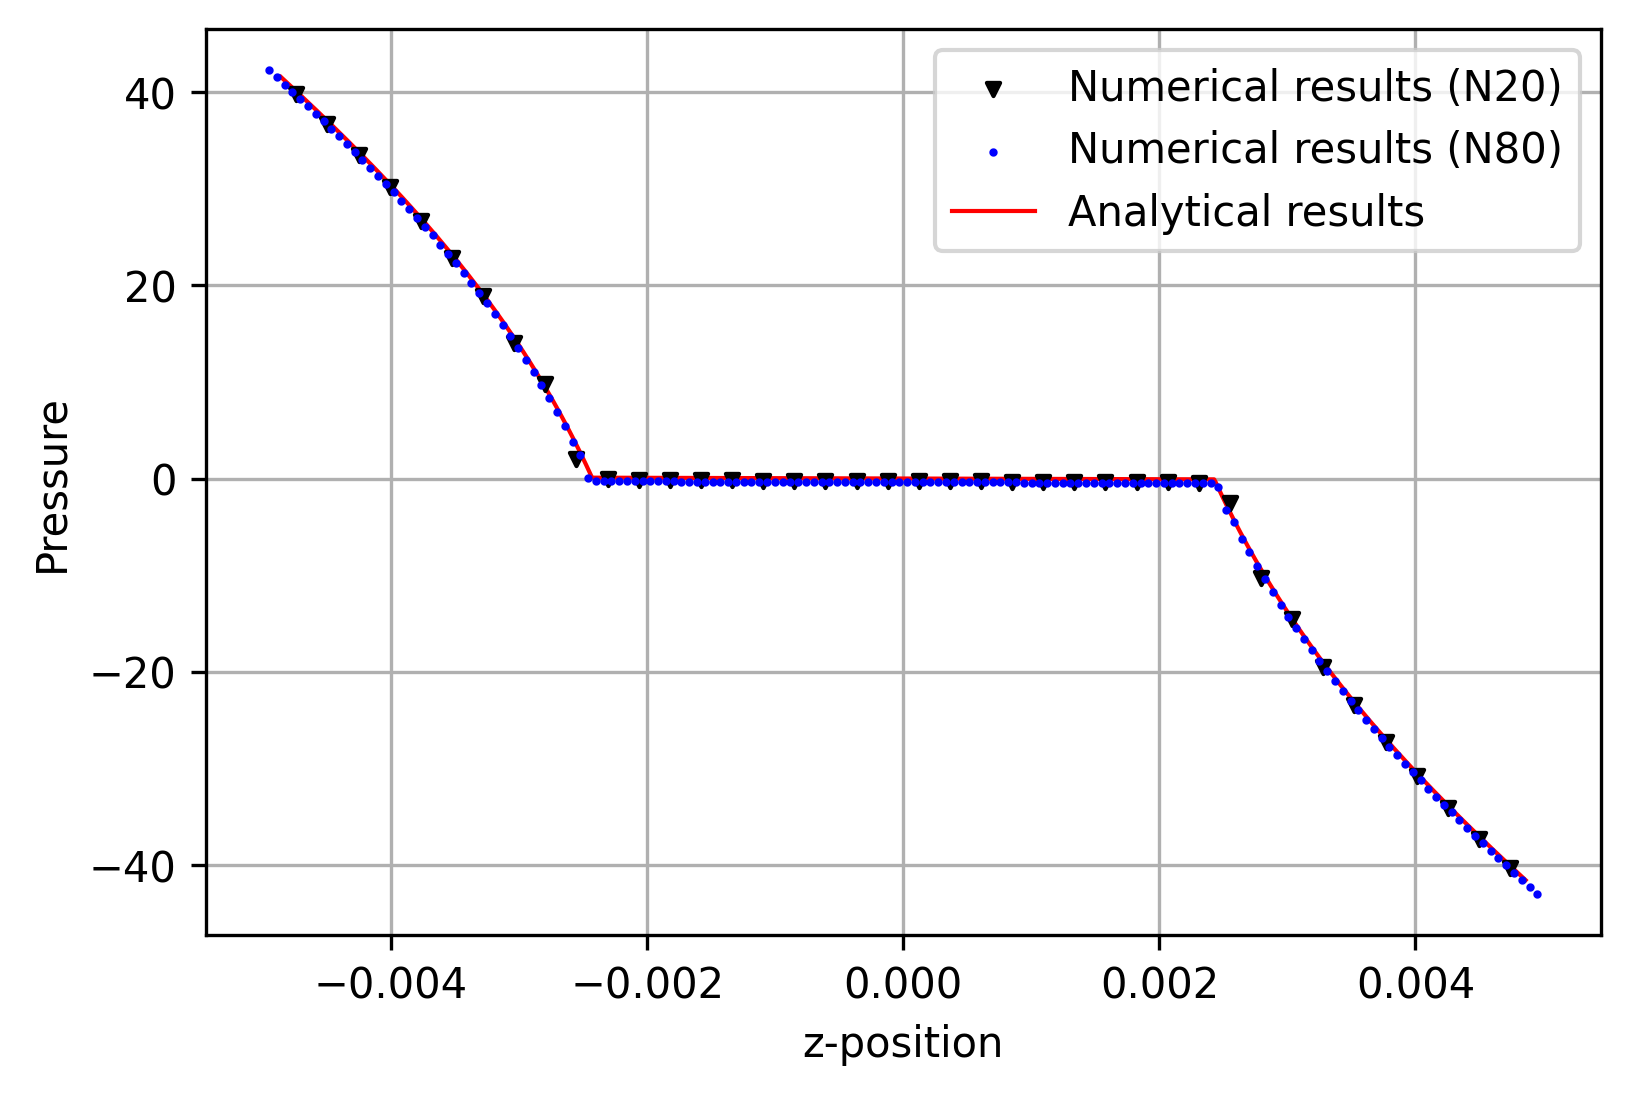

In [92]:
import numpy as np

def piecewise_function(xVal,yVal,z):
    """
    Define a piecewise function:
    
    f(x) = {
      x^2       if x < 0
      x + 2     if 0 <= x <= 2
      sqrt(x)   if x > 2
    }
    
    Parameters:
    x (array-like): Input array of x values.
    
    Returns:
    np.ndarray: Array of function values corresponding to input x values.
    """
    g = 9.80665
    rhol= 997
    rhog = 1.225
    r=0.00243
    x=xVal
    y=yVal
    # Define the conditions
    conditions = [
        (z < -r),
        (z >= -r) & (x <= r),
        (z > r)
    ]
    
    # Define the corresponding functions or values for each condition
    functions = [
        lambda  z: -(rhog-rhol)*rhol/(2*rhog+rhol)*g*z*(r**3)/(x**2+y**2 +z**2)**(3/2) - rhol*g*z,
        lambda  z: -3*rhog*rhol/(2*rhog + rhol)*g*z,
        lambda  z: -(rhog-rhol)*rhol/(2*rhog+rhol)*g*z*(r**3)/(x**2+y**2 +z**2)**(3/2) - rhol*g*z
    ]
    
    # Use np.piecewise to apply the conditions and functions
    return np.piecewise(z, conditions, functions)

r=0.00243
# Example usage
z_values = np.linspace(-2*r,2*r,1000) #pressureNum["Points:2"].values
#y_values = piecewise_function(0.0001215, 0.0001215, z_values)
y_values = piecewise_function(0.0001215/4, 0.0001215/4, z_values)
fig, ax = plt.subplots()

ax.scatter(pSampling['CellCenters:2'], pSampling['p'],marker='v', s=10, label="Numerical results (N20)", color='black', zorder=2)
ax.scatter(pSampN80['CellCenters:2'], pSampN80['p'], s=1, label="Numerical results (N80)", color='blue', zorder=3)
ax.plot(z_values, y_values,color='r', label="Analytical results", linewidth=1,zorder=1)

ax.set_ylabel("Pressure")
ax.set_xlabel("z-position")
#plt.xscale("log")
#plt.yscale("log")
ax.grid()
ax.set_axisbelow(True)
ax.legend()

plt.savefig('pressureZaxisFull_resComp.png', facecolor='w', dpi=400)
plt.show()


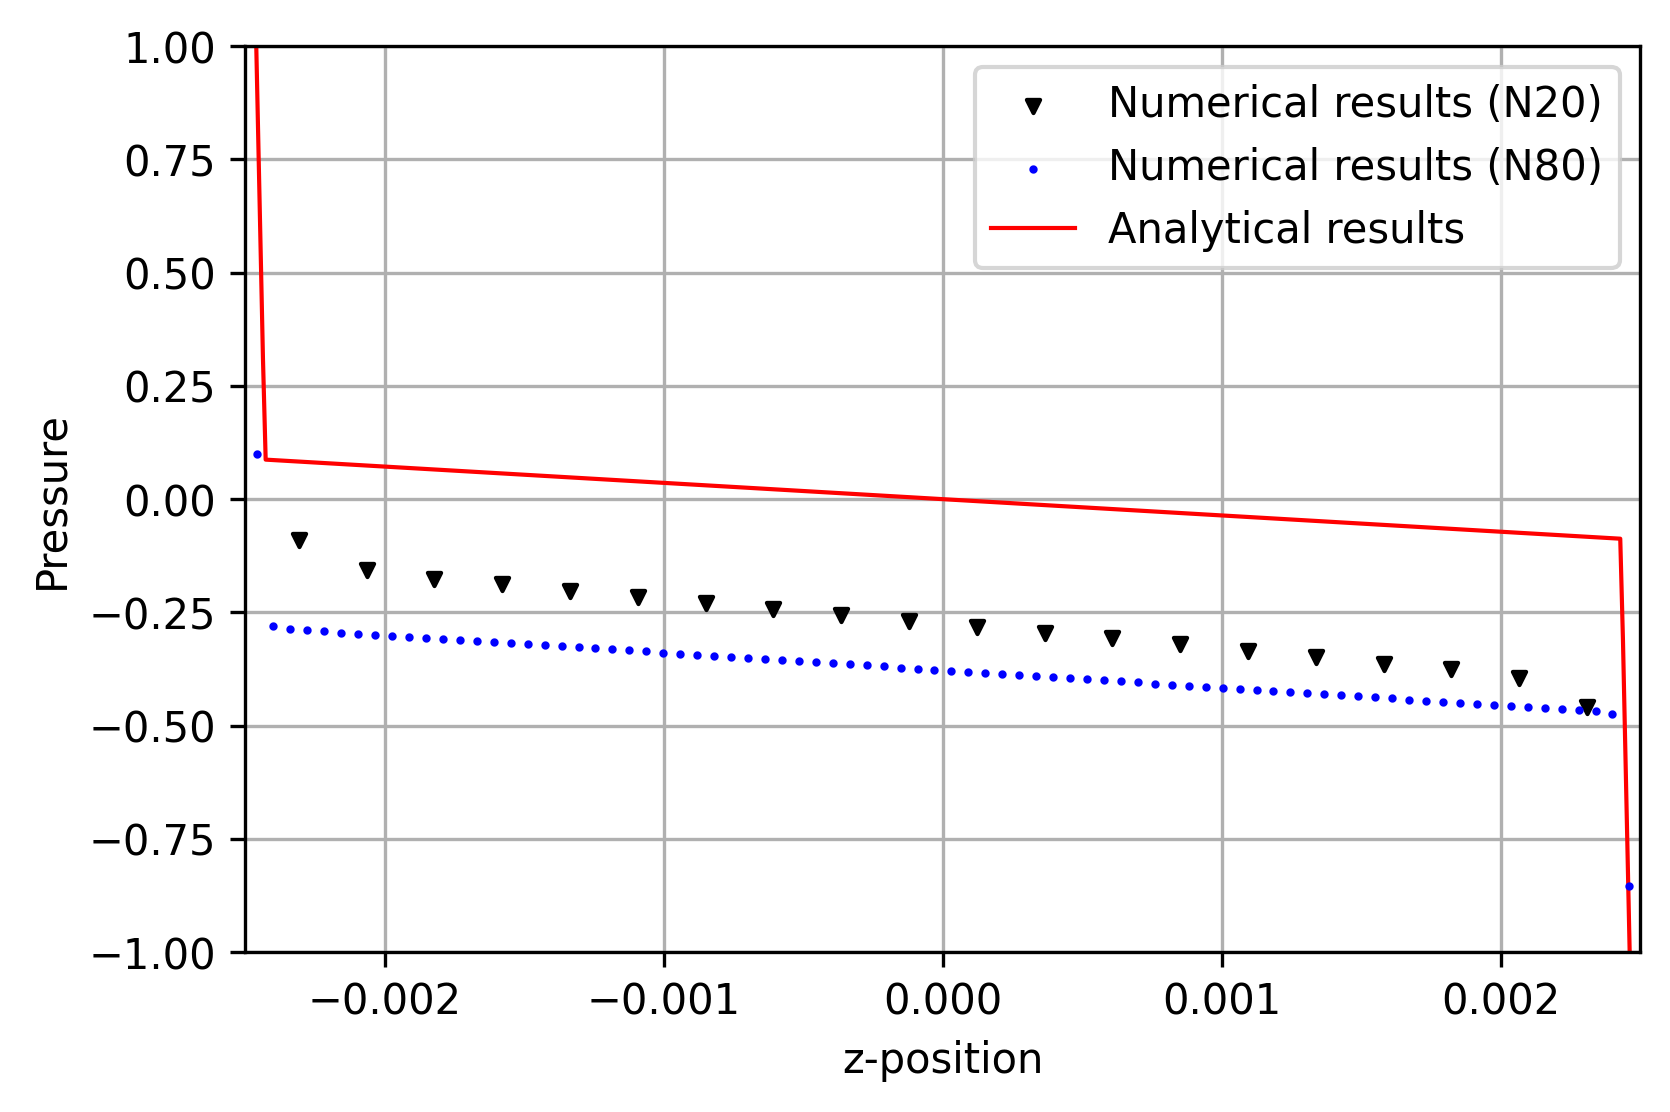

In [93]:
fig, ax = plt.subplots()

ax.scatter(pSampling['CellCenters:2'], pSampling['p'],marker='v', s=10, label="Numerical results (N20)", color='black', zorder=2)
ax.scatter(pSampN80['CellCenters:2'], pSampN80['p'], s=1, label="Numerical results (N80)", color='blue', zorder=3)
ax.plot(z_values, y_values,color='r', label="Analytical results", linewidth=1,zorder=1)

ax.set_ylabel("Pressure")
ax.set_xlabel("z-position")
#plt.xscale("log")
#plt.yscale("log")
ax.set_ylim(bottom=-1, top=1)
ax.set_xlim(left=-0.0025, right=0.0025)
ax.grid()
ax.set_axisbelow(True)
ax.legend()
#plt.xscale("log")
#plt.yscale("log")


plt.savefig('pressureZaxisGas_resComp.png', facecolor='w', dpi=400)
plt.show()

In [62]:
yExp= piecewise_function(0.0001215, 0.0001215, pSampling['CellCenters:2'].values)
yExp - pSampling['p'].values

array([ 0.31525962,  0.31496835,  0.32134692,  0.30409842,  0.36510753,
        0.20108862,  0.59179519, -0.26836406,  1.63119028,  0.17391485,
        0.23118053,  0.24197386,  0.24418782,  0.25556796,  0.26075372,
        0.26517566,  0.26939065,  0.29523038,  0.29956029,  0.30661192,
        0.30882777,  0.31962115,  0.37687784, -1.08047602,  0.8202592 ,
       -0.0394461 ,  0.35195666,  0.18850613,  0.24050116,  0.24087365,
        0.24196069,  0.31485923,  0.25123901,  0.27343132,  0.27736569,
        0.28140649,  0.28562178,  0.29004416,  0.25012178,  0.23349126])